In [1]:
!pip install safetensors

In [2]:
import os, sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import seaborn as sns
from safetensors.torch import load_file

from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
GITHUB_TOKEN = secrets.get_secret("GITHUB_TOKEN")
os.system(f'git clone https://{GITHUB_TOKEN}@github.com/m-j-r-q/Cura.git /kaggle/working/Cura')
sys.path.append('/kaggle/working/Cura/backend/src')

IMAGE_DIR  = '/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/images-224/images-224'
DATA_DIR   = '/kaggle/input/datasets/junaidrasul/cura-metadata'
OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Cloning into '/kaggle/working/Cura'...


Device: cuda


In [3]:
from dataset import CuraDataset, DISEASES, NUM_CLASSES
from transforms import val_transform
from model import build_model

test_df = pd.read_csv(f'{DATA_DIR}/test.csv')

test_loader = DataLoader(
    CuraDataset(test_df, IMAGE_DIR, val_transform),
    batch_size=16, shuffle=False, num_workers=0, pin_memory=False
)

print(f"Test images: {len(test_df)}")
print(f"Test batches: {len(test_loader)}")

Test images: 11196
Test batches: 700


In [4]:
def get_predictions(model, loader, device):
    model.eval()
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            images = images.to(device)
            probs  = torch.sigmoid(model(images))
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            
            if (i + 1) % 100 == 0:
                print(f"  Batch {i+1}/{len(loader)}")

    return (
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_probs,  axis=0)
    )

In [5]:
ARCHITECTURES = {
    'densenet121': 'densenet121_best.safetensors',
    'resnet50': 'resnet50_best.safetensors',
    'efficientnet_b0': 'efficientnet_b0_best.safetensors',
    'convnext_tiny': 'convnext_tiny_best.safetensors',
    'densenet169': 'densenet169_best.safetensors',
}
results = {}

for arch, filename in ARCHITECTURES.items():
    print(f"\nEvaluating {arch}...")
    
    model = build_model(
        arch,
        pretrained=False,
        dropout_p=0.2,
        internal_dropout_p=0.0
    ).to(device)
    state_dict = load_file(
        f'{DATA_DIR}/{filename}',
        device=str(device)
    )

    model.load_state_dict(state_dict)
    
    labels, probs = get_predictions(model, test_loader, device)
    results[arch] = {'labels': labels, 'probs': probs}
    
    del model
    torch.cuda.empty_cache()
    
    print(f"{arch} done.")


Evaluating densenet121...
  Batch 100/700
  Batch 200/700
  Batch 300/700
  Batch 400/700
  Batch 500/700
  Batch 600/700
  Batch 700/700
densenet121 done.

Evaluating resnet50...
  Batch 100/700
  Batch 200/700
  Batch 300/700
  Batch 400/700
  Batch 500/700
  Batch 600/700
  Batch 700/700
resnet50 done.

Evaluating efficientnet_b0...
  Batch 100/700
  Batch 200/700
  Batch 300/700
  Batch 400/700
  Batch 500/700
  Batch 600/700
  Batch 700/700
efficientnet_b0 done.

Evaluating convnext_tiny...
  Batch 100/700
  Batch 200/700
  Batch 300/700
  Batch 400/700
  Batch 500/700
  Batch 600/700
  Batch 700/700
convnext_tiny done.

Evaluating densenet169...
  Batch 100/700
  Batch 200/700
  Batch 300/700
  Batch 400/700
  Batch 500/700
  Batch 600/700
  Batch 700/700
densenet169 done.


In [6]:
auc_data = {}

for arch in ARCHITECTURES:
    labels = results[arch]['labels']
    probs  = results[arch]['probs']
    
    aucs = []
    for i in range(NUM_CLASSES):
        if labels[:, i].sum() > 0:
            auc = roc_auc_score(labels[:, i], probs[:, i])
        else:
            auc = float('nan')
        aucs.append(auc)
    
    auc_data[arch] = aucs

auc_df = pd.DataFrame(auc_data, index=DISEASES)
auc_df['mean'] = auc_df.mean(axis=1)
auc_df.loc['MEAN'] = auc_df.mean()

print(auc_df.round(4).to_string())
auc_df.to_csv(f'{OUTPUT_DIR}/auc_results.csv')

                    densenet121  resnet50  efficientnet_b0  convnext_tiny  densenet169    mean
Atelectasis              0.8255    0.8256           0.8053         0.8255       0.8188  0.8201
Cardiomegaly             0.9067    0.9018           0.8984         0.9167       0.9146  0.9076
Effusion                 0.8906    0.8884           0.8842         0.8935       0.8901  0.8894
Infiltration             0.7191    0.7165           0.7163         0.7208       0.7154  0.7176
Mass                     0.8659    0.8556           0.8315         0.8680       0.8635  0.8569
Nodule                   0.7784    0.7800           0.7585         0.8004       0.7911  0.7817
Pneumonia                0.7812    0.7727           0.7558         0.7779       0.7938  0.7763
Pleural_Thickening       0.8256    0.7980           0.8175         0.8268       0.8141  0.8164
Pneumothorax             0.8687    0.8520           0.8613         0.8718       0.8600  0.8628
Consolidation            0.8065    0.8108         

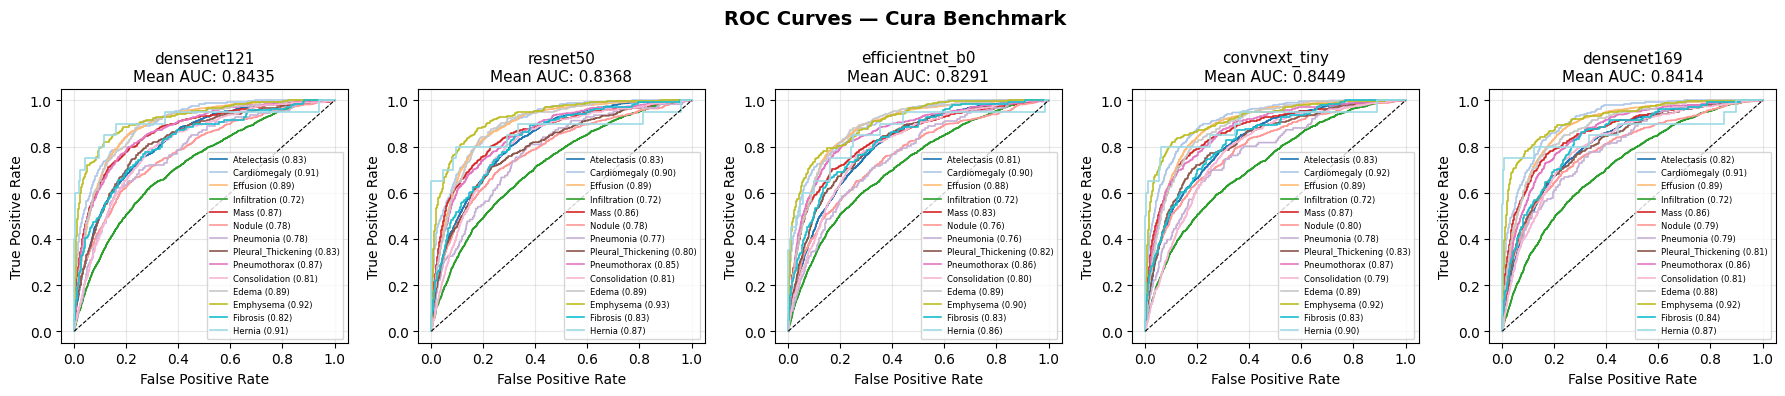

Saved.


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))

for ax, arch in zip(axes, ARCHITECTURES):
    labels = results[arch]['labels']
    probs  = results[arch]['probs']
    
    for i, disease in enumerate(DISEASES):
        if labels[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
            auc = roc_auc_score(labels[:, i], probs[:, i])
            ax.plot(fpr, tpr, color=colors[i], 
                   label=f'{disease} ({auc:.2f})', linewidth=1.2)
    
    ax.plot([0,1], [0,1], 'k--', linewidth=0.8)
    ax.set_title(f'{arch}\nMean AUC: {auc_df.loc["MEAN", arch]:.4f}', fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=6, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — Cura Benchmark', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

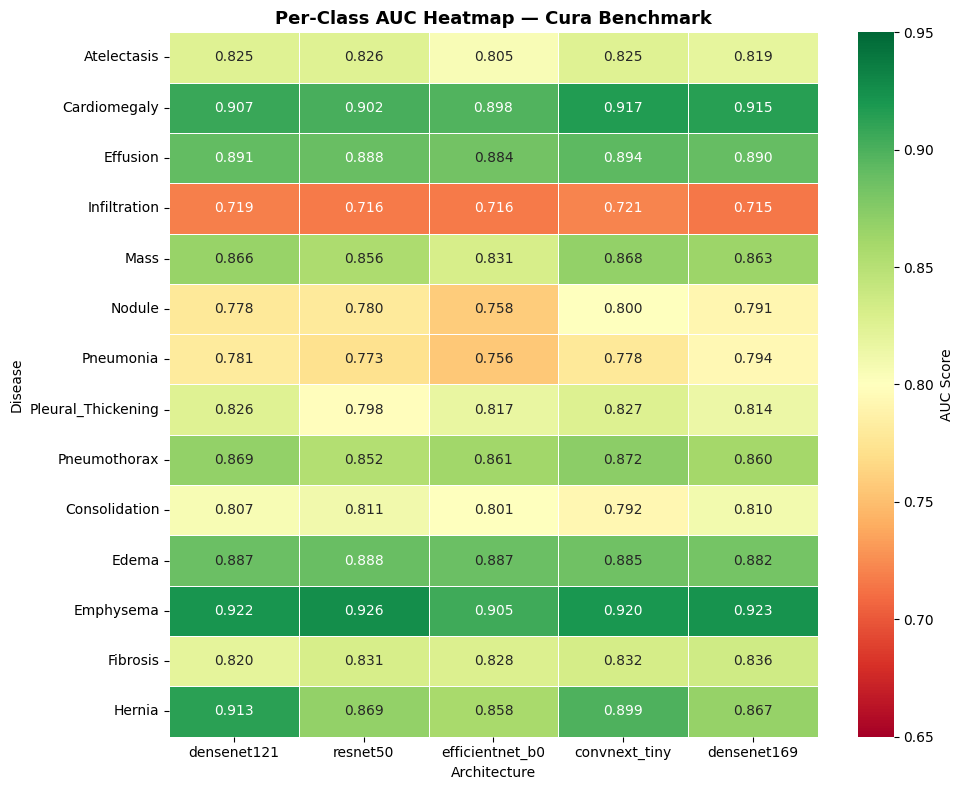

Saved.


In [8]:
plt.figure(figsize=(10, 8))

plot_df = auc_df.drop('mean', axis=1).drop('MEAN', axis=0)

sns.heatmap(
    plot_df,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0.65,
    vmax=0.95,
    linewidths=0.5,
    cbar_kws={'label': 'AUC Score'}
)

plt.title('Per-Class AUC Heatmap — Cura Benchmark', fontsize=13, fontweight='bold')
plt.xlabel('Architecture')
plt.ylabel('Disease')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [9]:
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.05, 0.96, 0.05)

f1_table = pd.DataFrame(index=DISEASES)
threshold_table = pd.DataFrame(index=DISEASES)

for arch in ARCHITECTURES:

    labels = results[arch]['labels']
    probs  = results[arch]['probs']

    model_f1 = []
    model_thresh = []

    print("\n" + "="*70)
    print(arch)
    print("="*70)

    for i, disease in enumerate(DISEASES):

        if labels[:, i].sum() == 0:
            model_f1.append(np.nan)
            model_thresh.append(np.nan)
            continue

        best_f1 = -1
        best_thresh = 0.5

        for t in thresholds:

            preds = (probs[:, i] >= t).astype(int)

            f1 = f1_score(
                labels[:, i],
                preds,
                zero_division=0
            )

            if f1 > best_f1:
                best_f1 = f1
                best_thresh = t

        model_f1.append(best_f1)
        model_thresh.append(best_thresh)

        print(f"{disease:25} F1={best_f1:.4f}   Threshold={best_thresh:.2f}")

    f1_table[arch] = model_f1
    threshold_table[arch] = model_thresh


densenet121
Atelectasis               F1=0.4241   Threshold=0.55
Cardiomegaly              F1=0.3898   Threshold=0.50
Effusion                  F1=0.5715   Threshold=0.55
Infiltration              F1=0.4147   Threshold=0.55
Mass                      F1=0.4130   Threshold=0.55
Nodule                    F1=0.2929   Threshold=0.55
Pneumonia                 F1=0.0893   Threshold=0.40
Pleural_Thickening        F1=0.2227   Threshold=0.50
Pneumothorax              F1=0.3664   Threshold=0.55
Consolidation             F1=0.2371   Threshold=0.50
Edema                     F1=0.2496   Threshold=0.45
Emphysema                 F1=0.4595   Threshold=0.50
Fibrosis                  F1=0.1729   Threshold=0.45
Hernia                    F1=0.5000   Threshold=0.55

resnet50
Atelectasis               F1=0.4125   Threshold=0.55
Cardiomegaly              F1=0.3931   Threshold=0.55
Effusion                  F1=0.5709   Threshold=0.55
Infiltration              F1=0.4077   Threshold=0.55
Mass                   

In [10]:
print("\nOptimal F1 Scores")
print(f1_table.round(4).to_string())

print("\nOptimal Thresholds")
print(threshold_table.round(2).to_string())


Optimal F1 Scores
                    densenet121  resnet50  efficientnet_b0  convnext_tiny  densenet169
Atelectasis              0.4241    0.4125           0.3816         0.4252       0.4144
Cardiomegaly             0.3898    0.3931           0.3851         0.3993       0.3867
Effusion                 0.5715    0.5709           0.5646         0.5699       0.5647
Infiltration             0.4147    0.4077           0.4163         0.4080       0.3971
Mass                     0.4130    0.4152           0.3787         0.4162       0.4233
Nodule                   0.2929    0.2946           0.2837         0.3227       0.3105
Pneumonia                0.0893    0.0917           0.0792         0.0963       0.1292
Pleural_Thickening       0.2227    0.2103           0.2053         0.2380       0.2375
Pneumothorax             0.3664    0.3368           0.3642         0.3601       0.3309
Consolidation            0.2371    0.2346           0.2251         0.2094       0.2426
Edema                   

In [11]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

labels = results['densenet121']['labels']

ensembles = {
    'DenseNet121 + DenseNet169 + ConvNeXt': 
        ['densenet121', 'densenet169', 'convnext_tiny'],
    'DenseNet121 + ResNet50 + ConvNeXt':    
        ['densenet121', 'resnet50', 'convnext_tiny'],
    'DenseNet121 + ResNet50 + ConvNeXt + DenseNet169':    
        ['densenet121', 'resnet50', 'convnext_tiny', 'densenet169'],
}

ensemble_results = {}

for name, archs in ensembles.items():
    probs = np.mean([results[a]['probs'] for a in archs], axis=0)
    aucs  = [
        roc_auc_score(labels[:, i], probs[:, i])
        if labels[:, i].sum() > 0 else 0.5
        for i in range(NUM_CLASSES)
    ]
    ensemble_results[name] = {'probs': probs, 'aucs': aucs}
    print(f"{name}.")
    print(f"AUC: {np.mean(aucs):.4f}")
    print("")

DenseNet121 + DenseNet169 + ConvNeXt.
AUC: 0.8539

DenseNet121 + ResNet50 + ConvNeXt.
AUC: 0.8522

DenseNet121 + ResNet50 + ConvNeXt + DenseNet169.
AUC: 0.8538



In [14]:
print(f"\n{'Disease':25} {'Ensemble 1':>30} {'Ensemble 2':>30} {'Ensemble 3':>30}")
print("-" * 115)

for i, disease in enumerate(DISEASES):
    auc_a = ensemble_results['DenseNet121 + DenseNet169 + ConvNeXt']['aucs'][i]
    auc_b = ensemble_results['DenseNet121 + ResNet50 + ConvNeXt']['aucs'][i]
    auc_c = ensemble_results['DenseNet121 + ResNet50 + ConvNeXt + DenseNet169']['aucs'][i]
    winner = ' ←'
    print(f"  {disease:25} {auc_a:>30.4f}{winner if (auc_a > auc_b and auc_a > auc_c) else ''} {auc_b:>30.4f}{winner if (auc_b > auc_a and auc_b > auc_c) else ''} {auc_c:>30.4f}{winner if (auc_c > auc_a and auc_c > auc_b) else ''}")


Disease                                       Ensemble 1                     Ensemble 2                     Ensemble 3
-------------------------------------------------------------------------------------------------------------------
  Atelectasis                                       0.8332                         0.8343 ←                         0.8342
  Cardiomegaly                                      0.9238 ←                         0.9213                         0.9231
  Effusion                                          0.8969                         0.8962                         0.8969 ←
  Infiltration                                      0.7270                         0.7286                         0.7288 ←
  Mass                                              0.8801 ←                         0.8766                         0.8788
  Nodule                                            0.8023 ←                         0.7975                         0.8012
  Pneumonia               

In [15]:
# Pick the better ensemble
best_name  = max(ensemble_results, key=lambda n: np.mean(ensemble_results[n]['aucs']))
best_probs = ensemble_results[best_name]['probs']
print(f"Winning ensemble: {best_name}\n")

thresholds = {}
for i, disease in enumerate(DISEASES):
    if labels[:, i].sum() == 0:
        thresholds[disease] = 0.5
        continue
    best_f1, best_thresh = 0.0, 0.5
    for thresh in np.arange(0.1, 0.95, 0.05):
        f1 = f1_score(labels[:, i], (best_probs[:, i] >= thresh).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    thresholds[disease] = round(float(best_thresh), 2)
    print(f"  {disease:25} threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")

import json
with open('/kaggle/working/ensemble_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print(f"\nMean AUC: {np.mean(ensemble_results[best_name]['aucs']):.4f}")
print("Saved ensemble_thresholds.json")

Winning ensemble: DenseNet121 + DenseNet169 + ConvNeXt

  Atelectasis               threshold: 0.55  F1: 0.4323
  Cardiomegaly              threshold: 0.55  F1: 0.3931
  Effusion                  threshold: 0.55  F1: 0.5815
  Infiltration              threshold: 0.55  F1: 0.4156
  Mass                      threshold: 0.55  F1: 0.4295
  Nodule                    threshold: 0.50  F1: 0.3342
  Pneumonia                 threshold: 0.45  F1: 0.1053
  Pleural_Thickening        threshold: 0.45  F1: 0.2381
  Pneumothorax              threshold: 0.50  F1: 0.3591
  Consolidation             threshold: 0.45  F1: 0.2417
  Edema                     threshold: 0.50  F1: 0.2691
  Emphysema                 threshold: 0.45  F1: 0.4953
  Fibrosis                  threshold: 0.45  F1: 0.1787
  Hernia                    threshold: 0.60  F1: 0.6207

Mean AUC: 0.8539
Saved ensemble_thresholds.json
